In [1]:
# ============================================================
# Titanic Classification Tree (CART) - Simple Example
# ============================================================

# Import libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------
titanic = sns.load_dataset("titanic")   # Titanic dataset from seaborn

print("First rows of the dataset:")
print(titanic.head())


First rows of the dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


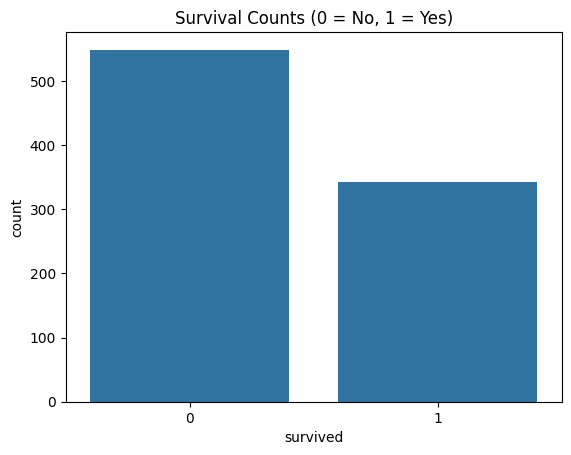

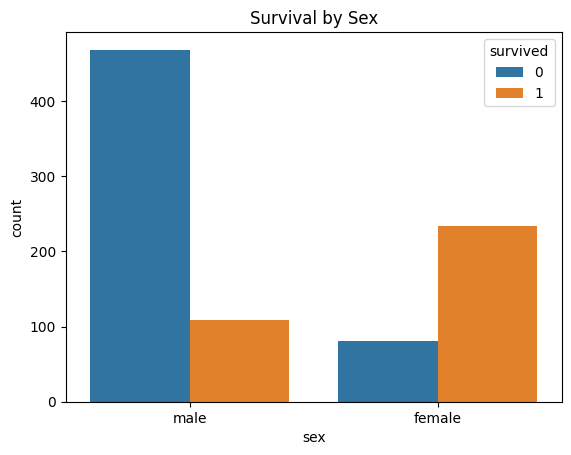

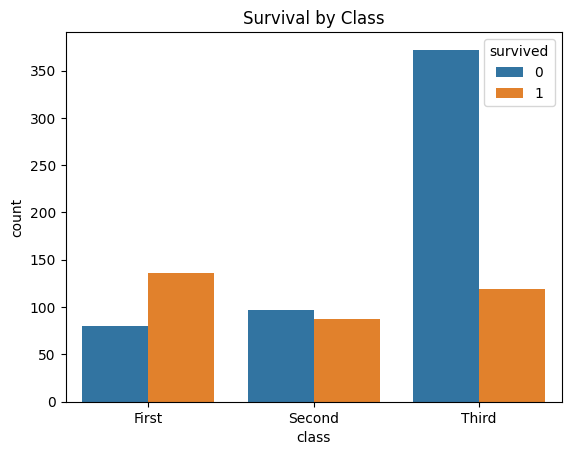

In [3]:
# ------------------------------------------------------------
# 2. Simple Exploratory Data Analysis (EDA)
# ------------------------------------------------------------

# Countplot of survival
sns.countplot(x="survived", data=titanic)
plt.title("Survival Counts (0 = No, 1 = Yes)")
plt.show()

# Survival by sex
sns.countplot(x="sex", hue="survived", data=titanic)
plt.title("Survival by Sex")
plt.show()

# Survival by class
sns.countplot(x="class", hue="survived", data=titanic)
plt.title("Survival by Class")
plt.show()



In [12]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [13]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# ------------------------------------------------------------
# 3. Data Preparation
# ------------------------------------------------------------
# Select a few useful columns
data = titanic[["survived", "pclass", "sex", "age", "fare", "alone"]]

# Drop missing values (for simplicity)
data = data.dropna()

# Convert categorical columns to numeric
data = pd.get_dummies(data, drop_first=True)

print("\nColumns after encoding:")
print(data.head())


Columns after encoding:
   survived  pclass   age     fare  alone  sex_male
0         0       3  22.0   7.2500  False      True
1         1       1  38.0  71.2833  False     False
2         1       3  26.0   7.9250   True     False
3         1       1  35.0  53.1000  False     False
4         0       3  35.0   8.0500   True      True


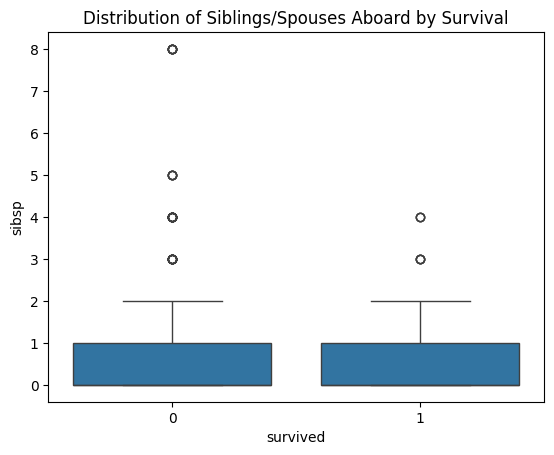

In [14]:
# Boxplot of sibsp by survival
sns.boxplot(x="survived", y="sibsp", data=titanic)
plt.title("Distribution of Siblings/Spouses Aboard by Survival")
plt.show()

In [17]:
# Calculate the proportion of survived by class
survival_by_class = titanic.groupby('class')['survived'].mean()

# Display the result as a table
print("\nProportion of survived by class (in percentages):")
print(survival_by_class.to_frame().rename(columns={'survived': 'Survival Rate (%)'}))


Proportion of survived by class (in percentages):
        Survival Rate (%)
class                    
First            0.629630
Second           0.472826
Third            0.242363


/tmp/ipython-input-1220258228.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class = titanic.groupby('class')['survived'].mean()


In [6]:
# Builds the model!

# Features (X) and Target (y)
X = data.drop("survived", axis=1)
y = data["survived"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
# ------------------------------------------------------------
# 4. Build a CART Decision Tree
# ------------------------------------------------------------
tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # limit depth for easy visualization
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [8]:
# ------------------------------------------------------------
# 5. Evaluate the model
# ------------------------------------------------------------
y_pred = tree.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Confusion Matrix:
[[109  17]
 [ 34  55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       126
           1       0.76      0.62      0.68        89

    accuracy                           0.76       215
   macro avg       0.76      0.74      0.75       215
weighted avg       0.76      0.76      0.76       215



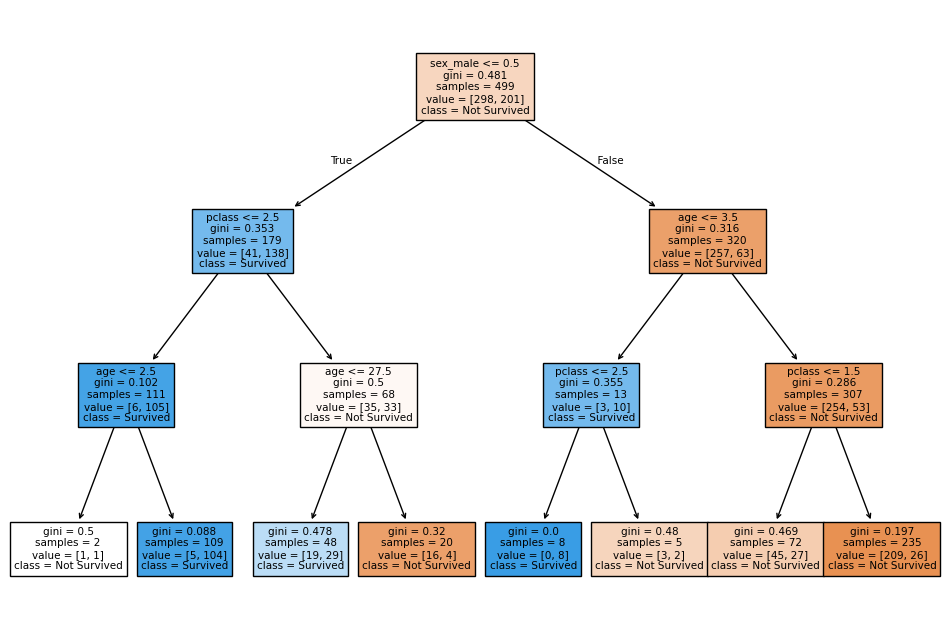

In [9]:
# ------------------------------------------------------------
# 6. Visualize the Tree
# ------------------------------------------------------------
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)
plt.show()